# 04. Money sizing and the promise-date simulator

## What we're doing and why

The earlier notebooks estimate *how much* lateness hurts reviews. This one turns that into business numbers:

1. **Direct exposure:** how many orders, and how much GMV, arrive late.
2. **Extra low reviews caused by lateness:** late orders × the causal effect on the chance of a 1–2 star review (from Test 2, as the plan says).
3. **Lost repeat customers:** converted to money only if Test 3 was significant; otherwise shown as a labelled range.
4. **Promise-date simulator:** what happens to the late rate and to low reviews if the promised date is moved by k days (k = −5 … +5).

Every assumption is listed in a table and saved to `outputs/tables/`.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyfixest as pf
from src.db import run_query

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
fe = pd.read_csv("../outputs/tables/test2_fe_results.csv")
rdd = pd.read_csv("../outputs/tables/test1_rdd_results.csv")
repeat = pd.read_csv("../outputs/tables/test3_repeat_purchase.csv")

beta_low = fe[fe["outcome"] == "low_review"]["estimate"].values[0]
beta_low_ci_low = fe[fe["outcome"] == "low_review"]["ci_low"].values[0]
beta_low_ci_high = fe[fe["outcome"] == "low_review"]["ci_high"].values[0]

rdd_main = rdd[rdd["test"] == "main"]
rdd_low = rdd_main[rdd_main["outcome"] == "low_review"]["estimate"].values[0]

repeat_beta = repeat["estimate"].values[0]
repeat_ci_low = repeat["ci_low"].values[0]
repeat_ci_high = repeat["ci_high"].values[0]
repeat_p = repeat["p"].values[0]

print("Test 2 effect of late on P(low review):", beta_low, "CI", beta_low_ci_low, beta_low_ci_high)
print("Test 1 RDD effect on P(low review):", rdd_low)
print("Test 3 effect on repurchase:", repeat_beta, "p =", repeat_p)

Test 2 effect of late on P(low review): 0.5186078602492002 CI 0.5045883804633696 0.5326273400350309
Test 1 RDD effect on P(low review): 0.0018783910563713
Test 3 effect on repurchase: -0.0032058891221057 p = 0.1504604319063931


In [3]:
orders = run_query("""
    SELECT order_id, customer_state, days_late, is_late, order_value, review_score, low_review
    FROM marts.fct_orders
    WHERE is_delivered = 1
""")
orders["order_value"] = orders["order_value"].astype(float)
orders["days_late"] = orders["days_late"].astype(int)

n_delivered = len(orders)
n_late = orders["is_late"].sum()
late_gmv = orders[orders["is_late"] == 1]["order_value"].sum()
total_gmv = orders["order_value"].sum()

print("Delivered orders:", n_delivered)
print("Late orders:", n_late, "=", round(100 * n_late / n_delivered, 2), "%")
print("GMV of late orders:", round(late_gmv), "=", round(100 * late_gmv / total_gmv, 2), "% of delivered GMV")

Delivered orders: 96470
Late orders: 6534 = 6.77 %
GMV of late orders: 985924 = 7.46 % of delivered GMV


In [4]:
extra_low = n_late * beta_low
extra_low_ci_low = n_late * beta_low_ci_low
extra_low_ci_high = n_late * beta_low_ci_high
extra_low_rdd = n_late * rdd_low

total_low = orders["low_review"].sum()
share_of_low_caused = extra_low / total_low

print("Extra low reviews caused by lateness (Test 2):", round(extra_low), "CI", round(extra_low_ci_low), "-", round(extra_low_ci_high))
print("Same using RDD estimate (check):", round(extra_low_rdd))
print("All low reviews among delivered orders:", total_low)
print("Share of all low reviews caused by lateness:", round(100 * share_of_low_caused, 1), "%")

Extra low reviews caused by lateness (Test 2): 3389 CI 3297 - 3480
Same using RDD estimate (check): 12
All low reviews among delivered orders: 12272.0
Share of all low reviews caused by lateness: 27.6 %


In [5]:
repeat_gmv = run_query("""
    WITH valid AS (
        SELECT customer_unique_id, purchase_date, order_value, purchase_ts, order_id
        FROM marts.fct_orders
        WHERE order_status NOT IN ('canceled', 'unavailable')
    ),
    first_order AS (
        SELECT customer_unique_id, first_order_id, purchase_date
        FROM causal.repeat_sample
        WHERE repurchase_180 = 1
    )
    SELECT
        f.customer_unique_id,
        SUM(v.order_value) AS repeat_gmv_180
    FROM first_order f
    JOIN valid v ON f.customer_unique_id = v.customer_unique_id
    WHERE v.purchase_date > f.purchase_date
      AND v.purchase_date <= f.purchase_date + 180
    GROUP BY f.customer_unique_id
""")
repeat_gmv["repeat_gmv_180"] = repeat_gmv["repeat_gmv_180"].astype(float)
avg_repeat_gmv = repeat_gmv["repeat_gmv_180"].mean()

late_first_orders = run_query("""
    SELECT COUNT(*) AS n
    FROM causal.repeat_sample
    WHERE late_first_order = 1
""")["n"].values[0]

lost_customers_low = -repeat_ci_high * late_first_orders
lost_customers_high = -repeat_ci_low * late_first_orders
lost_gmv_low = lost_customers_low * avg_repeat_gmv
lost_gmv_high = lost_customers_high * avg_repeat_gmv

print("Average 180-day GMV of a returning customer:", round(avg_repeat_gmv, 2))
print("Late first orders in the Test 3 sample:", late_first_orders)
print("Lost repeat customers, 95% CI range:", round(lost_customers_low), "to", round(lost_customers_high))
print("Lost repeat GMV, 95% CI range:", round(lost_gmv_low), "to", round(lost_gmv_high))

Average 180-day GMV of a returning customer: 136.44
Late first orders in the Test 3 sample: 3670
Lost repeat customers, 95% CI range: -4 to 28
Lost repeat GMV, 95% CI range: -583 to 3793


In [6]:
if repeat_p < 0.05:
    repeat_label = "Significant at 5%: point estimate used"
    lost_gmv_point = -repeat_beta * late_first_orders * avg_repeat_gmv
else:
    repeat_label = "NOT statistically significant: shown only as a range, not counted in the total"
    lost_gmv_point = None

money = pd.DataFrame([
    {"item": "Delivered orders", "value": n_delivered, "source_or_assumption": "fct_orders, is_delivered = 1, full period"},
    {"item": "Late orders", "value": n_late, "source_or_assumption": "days_late >= 1"},
    {"item": "Late-order share (%)", "value": round(100 * n_late / n_delivered, 2), "source_or_assumption": "late / delivered"},
    {"item": "GMV of late orders (R$)", "value": round(late_gmv, 0), "source_or_assumption": "sum of item price of late orders"},
    {"item": "Late GMV share (%)", "value": round(100 * late_gmv / total_gmv, 2), "source_or_assumption": "late GMV / delivered GMV"},
    {"item": "Causal effect of late on P(review <= 2)", "value": round(beta_low, 4), "source_or_assumption": "Test 2 seller FE (pre-registered choice)"},
    {"item": "Extra low reviews caused by lateness", "value": round(extra_low, 0), "source_or_assumption": "late orders x Test 2 effect"},
    {"item": "Extra low reviews, 95% CI low", "value": round(extra_low_ci_low, 0), "source_or_assumption": "late orders x CI low"},
    {"item": "Extra low reviews, 95% CI high", "value": round(extra_low_ci_high, 0), "source_or_assumption": "late orders x CI high"},
    {"item": "Extra low reviews using RDD effect (check)", "value": round(extra_low_rdd, 0), "source_or_assumption": "late orders x Test 1 RDD effect (local to the cutoff)"},
    {"item": "Share of all low reviews caused by lateness (%)", "value": round(100 * share_of_low_caused, 1), "source_or_assumption": "extra low reviews / all low reviews on delivered orders"},
    {"item": "Test 3 effect on repurchase_180", "value": round(repeat_beta, 4), "source_or_assumption": repeat_label},
    {"item": "Avg 180-day GMV of a returning customer (R$)", "value": round(avg_repeat_gmv, 2), "source_or_assumption": "repeat orders within 180 days, Test 3 sample"},
    {"item": "Lost repeat GMV range, low (R$)", "value": round(lost_gmv_low, 0), "source_or_assumption": "late first orders x -CI high x avg repeat GMV"},
    {"item": "Lost repeat GMV range, high (R$)", "value": round(lost_gmv_high, 0), "source_or_assumption": "late first orders x -CI low x avg repeat GMV"},
])

money.to_csv("../outputs/tables/money_sizing.csv", index=False)
with open("../outputs/tables/money_sizing.md", "w") as f:
    f.write("# Money sizing\n\n")
    f.write(money.to_markdown(index=False))

money

,item,value,source_or_assumption
0,Delivered orders,"96,470.0000","fct_orders, is_delivered = 1, full period"
1,Late orders,"6,534.0000",days_late >= 1
2,Late-order share (%),6.7700,late / delivered
3,GMV of late orders (R$),"985,924.0000",sum of item price of late orders
4,Late GMV share (%),7.4600,late GMV / delivered GMV
5,Causal effect of late on P(review <= 2),0.5186,Test 2 seller FE (pre-registered choice)
6,Extra low reviews caused by lateness,"3,389.0000",late orders x Test 2 effect
7,"Extra low reviews, 95% CI low","3,297.0000",late orders x CI low
8,"Extra low reviews, 95% CI high","3,480.0000",late orders x CI high
9,Extra low reviews using RDD effect (check),12.0000,late orders x Test 1 RDD effect (local to the ...


In [7]:
states = ["ALL"] + sorted(orders["customer_state"].unique().tolist())

sim_rows = []
for state in states:
    if state == "ALL":
        d = orders
    else:
        d = orders[orders["customer_state"] == state]

    base_late = (d["days_late"] >= 1).sum()

    for k in range(-5, 6):
        new_days_late = d["days_late"] - k
        new_late = (new_days_late >= 1).sum()
        change_in_late = new_late - base_late

        row = {}
        row["state"] = state
        row["k_days_added"] = k
        row["n_orders"] = len(d)
        row["late_orders"] = new_late
        row["late_pct"] = 100 * new_late / len(d)
        row["change_in_late_orders"] = change_in_late
        row["change_in_low_reviews"] = change_in_late * beta_low
        sim_rows.append(row)

simulator = pd.DataFrame(sim_rows)
simulator.to_csv("../outputs/tables/simulator.csv", index=False)
simulator[simulator["state"] == "ALL"]

,state,k_days_added,n_orders,late_orders,late_pct,change_in_late_orders,change_in_low_reviews
0,ALL,-5,96470,14486,15.0161,7952,"4,123.9697"
1,ALL,-4,96470,12569,13.0289,6035,"3,129.7984"
2,ALL,-3,96470,10838,11.2346,4304,"2,232.0882"
3,ALL,-2,96470,9288,9.6279,2754,"1,428.2460"
4,ALL,-1,96470,7826,8.1124,1292,670.0414
5,ALL,0,96470,6534,6.7731,0,0.0000
6,ALL,1,96470,5709,5.9179,-825,-427.8515
7,ALL,2,96470,5164,5.3530,-1370,-710.4928
8,ALL,3,96470,4664,4.8347,-1870,-969.7967
9,ALL,4,96470,4211,4.3651,-2323,"-1,204.7261"


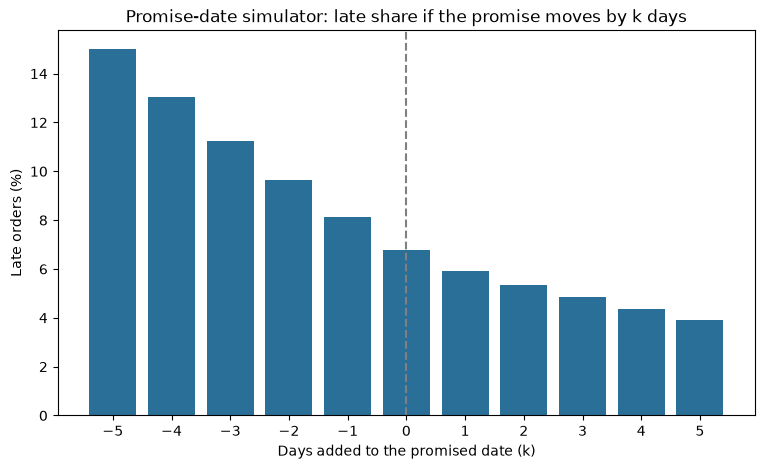

In [8]:
overall = simulator[simulator["state"] == "ALL"]

plt.figure(figsize=(9, 5))
plt.bar(overall["k_days_added"], overall["late_pct"], color="#2a6f97")
plt.axvline(0, color="grey", linestyle="--")
plt.xlabel("Days added to the promised date (k)")
plt.ylabel("Late orders (%)")
plt.title("Promise-date simulator: late share if the promise moves by k days")
plt.xticks(range(-5, 6))
plt.savefig("../outputs/figures/simulator_late_pct.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
kpi_monthly = run_query("""
    SELECT
        purchase_month,
        COUNT(*) AS n_orders,
        SUM(order_value) AS gmv,
        AVG(order_value) AS aov,
        100.0 * SUM(CASE WHEN is_delivered = 1 THEN is_late ELSE 0 END) / NULLIF(SUM(is_delivered), 0) AS late_pct,
        AVG(CASE WHEN is_delivered = 1 THEN review_score END) AS avg_review
    FROM marts.fct_orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
      AND purchase_month BETWEEN '2017-01-01' AND '2018-08-01'
    GROUP BY purchase_month
    ORDER BY purchase_month
""")
kpi_monthly.to_csv("../outputs/tableau/kpi_monthly.csv", index=False)
kpi_monthly.head()

,purchase_month,n_orders,gmv,aov,late_pct,avg_review
0,2017-01-01,787,"120,098.2700",152.6026,2.9333,4.1984
1,2017-02-01,1718,"244,959.3500",142.5840,2.9643,4.2033
2,2017-03-01,2617,"368,341.3200",140.7495,4.5562,4.1868
3,2017-04-01,2377,"353,842.9800",148.8612,6.5567,4.1367
4,2017-05-01,3640,"503,159.1900",138.2305,2.9901,4.2354


In [10]:
state_summary = run_query("""
    SELECT
        customer_state AS state,
        customer_region AS region,
        COUNT(*) AS n_orders,
        SUM(order_value) AS gmv,
        AVG(order_value) AS aov,
        100.0 * SUM(CASE WHEN is_delivered = 1 THEN is_late ELSE 0 END) / NULLIF(SUM(is_delivered), 0) AS late_pct,
        AVG(CASE WHEN is_delivered = 1 THEN review_score END) AS avg_review,
        AVG(CASE WHEN is_delivered = 1 THEN delivery_days END) AS avg_delivery_days,
        AVG(promised_days) AS avg_promised_days
    FROM marts.fct_orders
    WHERE order_status NOT IN ('canceled', 'unavailable')
    GROUP BY customer_state, customer_region
    ORDER BY customer_state
""")

state_names = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapa", "AM": "Amazonas", "BA": "Bahia",
    "CE": "Ceara", "DF": "Distrito Federal", "ES": "Espirito Santo", "GO": "Goias",
    "MA": "Maranhao", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Para", "PB": "Paraiba", "PR": "Parana", "PE": "Pernambuco", "PI": "Piaui",
    "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte", "RS": "Rio Grande do Sul",
    "RO": "Rondonia", "RR": "Roraima", "SC": "Santa Catarina", "SP": "Sao Paulo",
    "SE": "Sergipe", "TO": "Tocantins",
}
state_summary["state_name"] = state_summary["state"].map(state_names)
state_summary["country"] = "Brazil"
state_summary.to_csv("../outputs/tableau/state_summary.csv", index=False)
state_summary.head()

,state,region,n_orders,gmv,aov,late_pct,avg_review,avg_delivery_days,avg_promised_days,state_name,country
0,AC,North,81,"15,982.9500",197.3204,3.7500,4.0875,21.0000,41.7654,Acre,Brazil
1,AL,Northeast,411,"80,314.8100",195.4132,21.4106,3.8477,24.5013,33.1873,Alagoas,Brazil
2,AM,North,147,"22,356.8400",152.0873,2.7586,4.2431,26.3586,45.8571,Amazonas,Brazil
3,AP,North,68,"13,474.3000",198.1515,2.9851,4.2424,27.1791,46.7059,Amapa,Brazil
4,BA,Northeast,3344,"507,108.8300",151.6474,12.1622,3.9297,19.2786,30.0320,Bahia,Brazil


In [11]:
rdd_bins = pd.read_csv("../outputs/tables/rdd_bins.csv")
side = []
for value in rdd_bins["days_late"]:
    if value >= 1:
        side.append("Late")
    else:
        side.append("On time or early")
rdd_bins["side"] = side
rdd_bins.to_csv("../outputs/tableau/rdd_bins.csv", index=False)

simulator.to_csv("../outputs/tableau/simulator.csv", index=False)

scorecard = run_query("SELECT * FROM causal.seller_scorecard ORDER BY late_rank")
scorecard.to_csv("../outputs/tableau/seller_scorecard.csv", index=False)

categories = pd.read_csv("../outputs/tables/q03_top_categories.csv")
categories.to_csv("../outputs/tableau/top_categories.csv", index=False)

print("Tableau files written")

Tableau files written


## What this means for the business

**Summary of the numbers (full table in `outputs/tables/money_sizing.md`):**

- **Direct exposure:** 6,534 of 96,470 delivered orders (6.8%) were late, worth **R$986k of GMV** (7.5% of delivered GMV).
- **Reputation cost:** late orders × the Test 2 effect (+51.9 pp) = **about 3,390 extra 1–2 star reviews** (95% CI 3,300–3,480). That is **about 28% of all low reviews** on delivered orders.
- **Loyalty cost:** not statistically significant (Test 3). The 95% range is −R$0.6k to +R$3.8k of lost repeat GMV, which is tiny because so few customers return.

**Promise-date simulator** (assuming actual delivery times don't change):

| Days added to the promise (k) | Late share | Change in low reviews |
|---|---|---|
| −2 | 9.6% | +1,430 |
| 0 (today) | 6.8% | 0 |
| +2 | 5.4% | −710 |
| +3 | 4.8% | −970 |
| +5 | 3.9% | −1,440 |

**Limit:** a longer promise may put some customers off buying at all. This data only contains orders that were placed, so it can't measure that cost. The simulator gives the upper bound of the benefit, not a net effect.